In [1]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import faiss
import matplotlib.pyplot as plt
from PIL import Image

In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 5)

checkpoint = torch.load('../models/best_finetuned.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint)

embedding_extractor = nn.Sequential(*list(model.children())[:-1])
embedding_extractor.eval()
embedding_extractor.to(device)

print("Модель готова. На выходе будет вектор размером 512.")

Device: cuda
Модель готова. На выходе будет вектор размером 512.


In [3]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

data_dir = '../data/processed'
db_dataset = datasets.ImageFolder(f'{data_dir}/train', transform=transform)

db_loader = DataLoader(db_dataset, batch_size=32, shuffle=False)

all_embeddings = []
all_image_paths = [path for path, _ in db_dataset.samples]

print("Извлекаем эмбеддинги для базы данных...")

with torch.no_grad():
    for inputs, _ in db_loader:
        inputs = inputs.to(device)
        
        embeddings = embedding_extractor(inputs)
        
        embeddings = embeddings.view(embeddings.size(0), -1).cpu().numpy()
        
        embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
        
        all_embeddings.append(embeddings)

db_embeddings = np.vstack(all_embeddings).astype('float32')
print(f"Форма матрицы эмбеддингов: {db_embeddings.shape}") 

Извлекаем эмбеддинги для базы данных...
Форма матрицы эмбеддингов: (1798, 512)


In [ ]:
d = 512 
index = faiss.IndexFlatIP(d)
index.add(db_embeddings)
print(f"В индекс добавлено {index.ntotal} векторов.")

faiss_index_path = '../models/faiss_index.bin'
faiss.write_index(index, faiss_index_path)
print(f"FAISS индекс сохранен в {faiss_index_path}")

In [6]:
import json
import random
from pathlib import Path

# Генерируем метаданные квартир для каждой картинки
metadata = {}
for idx, path in enumerate(all_image_paths):
    room_type = Path(path).parent.name 
    
    price = round(random.uniform(5.0, 35.0), 1) # Цена от 5 до 35 млн
    area = random.randint(30, 120)              # Площадь от 30 до 120 кв.м.
    rooms = random.choice([1, 2, 3, 4])         # Количество комнат
    
    metadata[idx] = {
        "image_path": str(path),
        "room_type": room_type,
        "price_mln": price,
        "area_sqm": area,
        "rooms": rooms,
        "apartment_id": f"APT-{random.randint(1000, 9999)}"
    }

# Сохраняем метаданные в JSON
metadata_path = '../models/metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print(f"Метаданные квартир сохранены в {metadata_path}")

Метаданные квартир сохранены в ../models/metadata.json


In [7]:
# Функция для визуального поиска
def search_similar_images(query_image_path, top_k=4):

    image = Image.open(query_image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device) # добавляем batch_size=1
    
    with torch.no_grad():
        emb = embedding_extractor(input_tensor)
        emb = emb.view(1, -1).cpu().numpy()
        emb = emb / np.linalg.norm(emb, axis=1, keepdims=True)
        
    distances, indices = index.search(emb.astype('float32'), top_k)
    
    fig = plt.figure(figsize=(15, 5))

    ax = fig.add_subplot(1, top_k + 1, 1)
    ax.imshow(image)
    ax.set_title("Ваш запрос")
    ax.axis('off')
    
    for i in range(top_k):
        found_idx = indices[0][i]
        found_path = all_image_paths[found_idx]
        found_img = Image.open(found_path)
        similarity = distances[0][i]
        
        ax = fig.add_subplot(1, top_k + 1, i + 2)
        ax.imshow(found_img)
        ax.set_title(f"Найдено #{i+1}\nСходство: {similarity:.2f}")
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

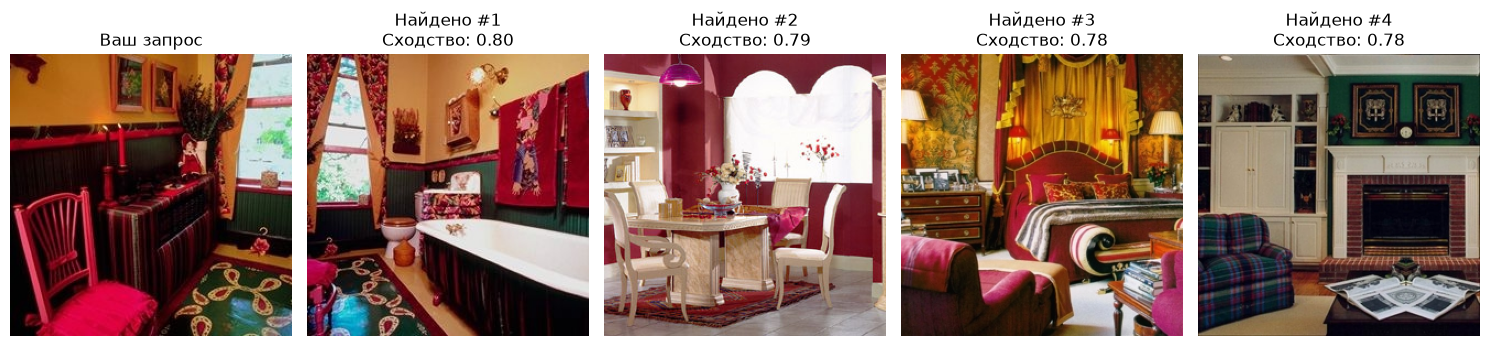

In [8]:
import random

test_dataset = datasets.ImageFolder(f'{data_dir}/test')
random_test_path, _ = random.choice(test_dataset.samples)

search_similar_images(random_test_path, top_k=4)